In [27]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [10]:
ruta = 'tested.csv'
df = pd.read_csv(ruta)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [14]:
# Filtramos las columnas que tienen más de un 90% de datos no-nulos
maxi = len(df) * 0.9
df = df.loc[:, df.notnull().sum() > maxi]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Embarked     418 non-null    object 
dtypes: float64(1), int64(5), object(4)
memory usage: 32.8+ KB


In [19]:
df = df.dropna()

In [20]:
duplicates = df.duplicated(keep=False)
dups = df[duplicates]
dups

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Embarked


In [21]:
df['Sex'].unique()
df['Embarked'].unique()

['Q', 'S', 'C']
Categories (3, object): ['C', 'Q', 'S']

In [26]:
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  417 non-null    int64   
 1   Survived     417 non-null    int64   
 2   Pclass       417 non-null    int64   
 3   Name         417 non-null    object  
 4   Sex          417 non-null    category
 5   SibSp        417 non-null    int64   
 6   Parch        417 non-null    int64   
 7   Ticket       417 non-null    object  
 8   Fare         417 non-null    float64 
 9   Embarked     417 non-null    category
dtypes: category(2), float64(1), int64(5), object(2)
memory usage: 30.4+ KB


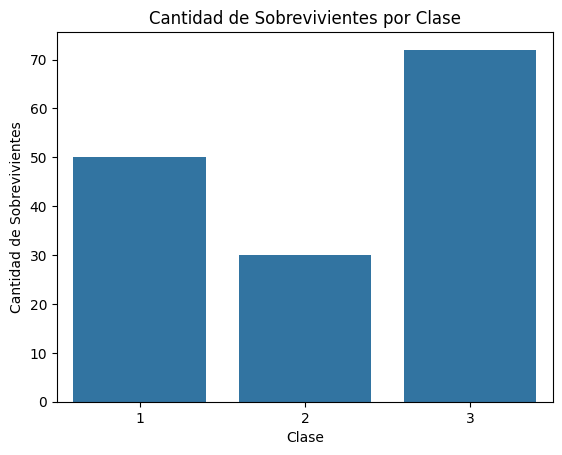

In [41]:
cantidad_survived = df.groupby('Pclass')['Survived'].sum()
sns.barplot(x=cantidad_survived.index, y=cantidad_survived.values)
plt.title('Cantidad de Sobrevivientes por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Sobrevivientes')
plt.show()

In [45]:
df['Fare'].describe()

count    417.000000
mean      35.627188
std       55.907576
min        0.000000
25%        7.895800
50%       14.454200
75%       31.500000
max      512.329200
Name: Fare, dtype: float64

In [ ]:
numerical_data = df.select_dtypes(include=[float, int])
# Calcular la correlación entre las columnas numéricas
correlacion = numerical_data.corr()
correlacion

,PassengerId,Survived,Pclass,SibSp,Parch,Fare
PassengerId,1.000000,-0.024117,-0.025800,0.003259,0.042650,0.008211
Survived,-0.024117,1.000000,-0.107203,0.099136,0.158534,0.191514
Pclass,-0.025800,-0.107203,1.000000,0.002136,0.019581,-0.577147
SibSp,0.003259,0.099136,0.002136,1.000000,0.306566,0.171539
Parch,0.042650,0.158534,0.019581,0.306566,1.000000,0.230046
Fare,0.008211,0.191514,-0.577147,0.171539,0.230046,1.000000


Text(0.5, 1.0, 'correlaciones')

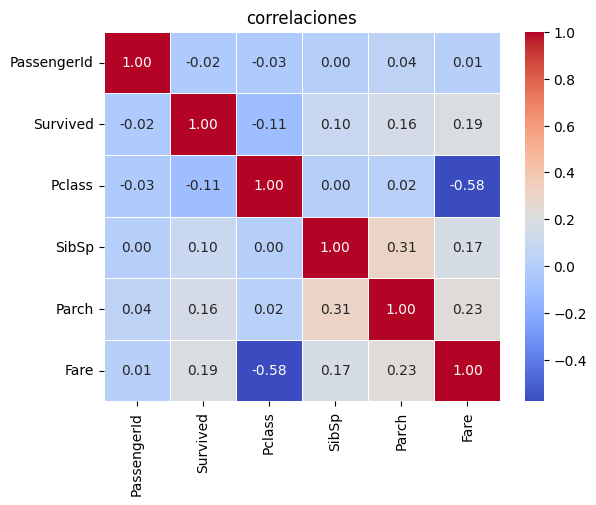

In [49]:
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('correlaciones')

In [53]:
corre = df.Fare.corr(df.Pclass)
corre

np.float64(-0.5771473123362401)

<Axes: xlabel='Survived'>

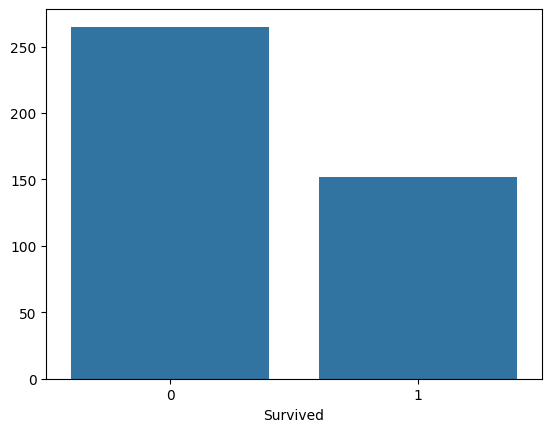

In [58]:
survi_c = df['Survived'].value_counts()
sns.barplot(x=survi_c.index, y=survi_c.values)

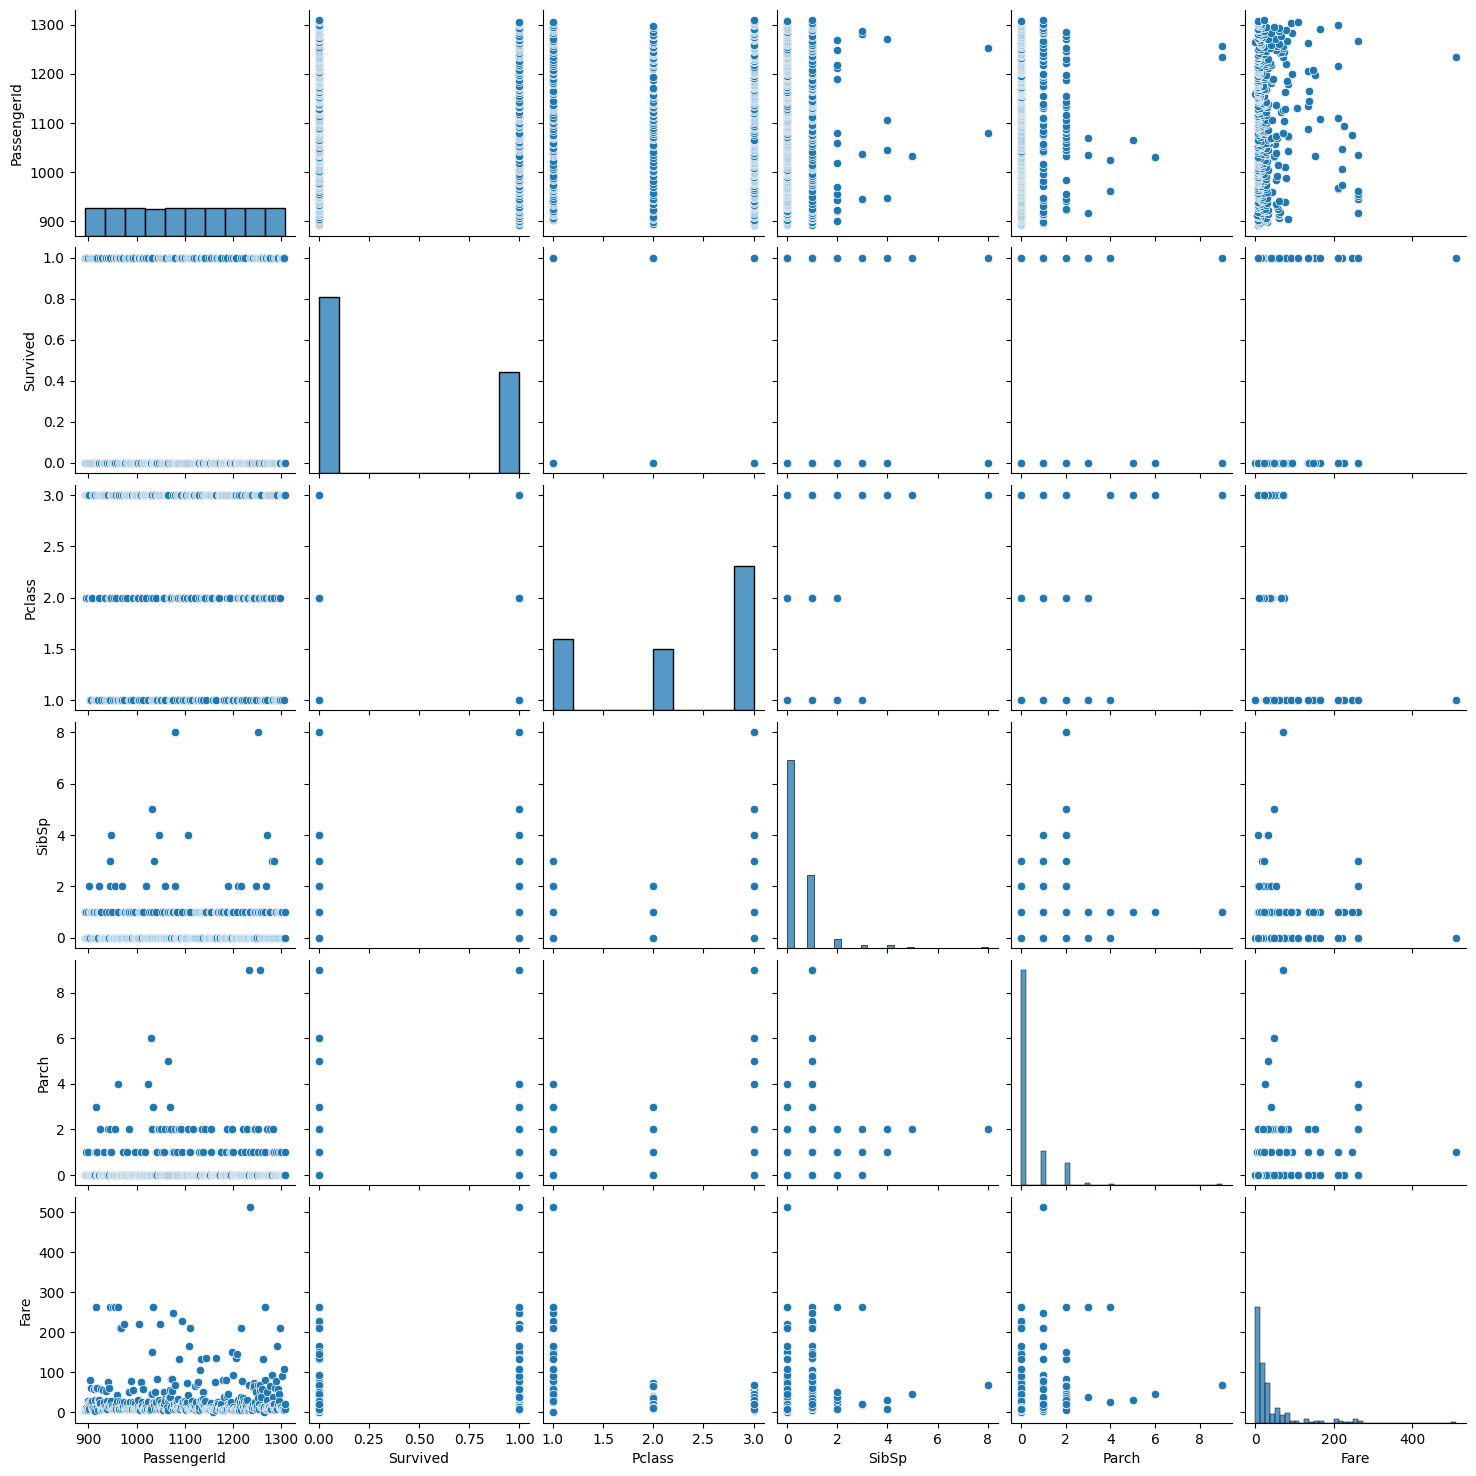

In [60]:
sns.pairplot(df)

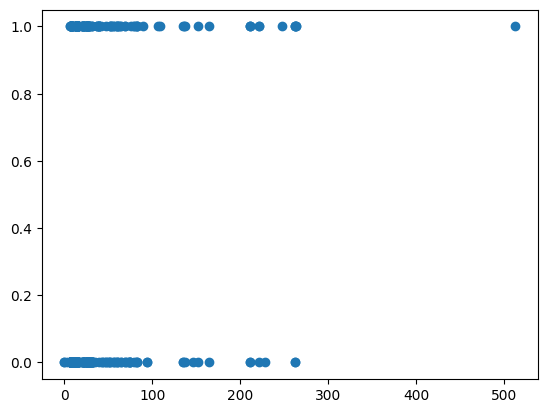

In [68]:
plt.scatter(df['Fare'], df['Survived'])

C:\Users\Equipo\AppData\Local\Temp\ipykernel_9388\3518756970.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cantidad_survived = df.groupby('Sex')['Survived'].sum()


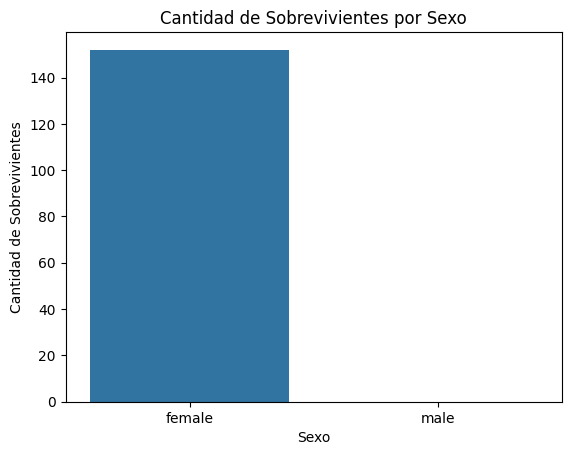

In [71]:
cantidad_survived = df.groupby('Sex')['Survived'].sum()
sns.barplot(x=cantidad_survived.index, y=cantidad_survived.values)
plt.title('Cantidad de Sobrevivientes por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Sobrevivientes')
plt.show()

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  417 non-null    int64   
 1   Survived     417 non-null    int64   
 2   Pclass       417 non-null    int64   
 3   Name         417 non-null    object  
 4   Sex          417 non-null    category
 5   SibSp        417 non-null    int64   
 6   Parch        417 non-null    int64   
 7   Ticket       417 non-null    object  
 8   Fare         417 non-null    float64 
 9   Embarked     417 non-null    category
dtypes: category(2), float64(1), int64(5), object(2)
memory usage: 30.4+ KB


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir las variables dependiente e independiente
X = df[['Pclass']]  # Variable independiente
y = df['Survived']  # Variable dependiente

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # test_size 0.2 son 20% de prueba, random_state numero aleatorio para empezar

# Crear el modelo de regresión lineal
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# rmse r2 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

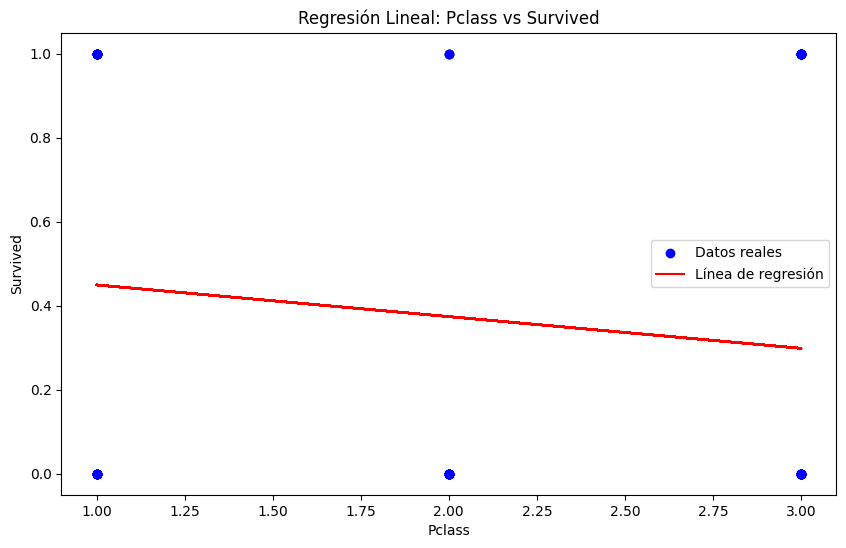

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de dispersión
plt.figure(figsize=(10, 6))

# Graficar los puntos reales (scatter plot)
plt.scatter(X_test, y_test, color='blue', label='Datos reales')

# Graficar la línea de regresión (predicciones)
plt.plot(X_test, y_pred, color='red', label='Línea de regresión')

# Etiquetas y título
plt.title('Regresión Lineal: Pclass vs Survived')
plt.xlabel('Pclass')
plt.ylabel('Survived')

# Agregar leyenda
plt.legend()

# Mostrar gráfico
plt.show()


In [ ]:
X = df[['Pclass']]  # Variable independiente
y = df['Survived']  # Variable dependiente

# Dividir en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Regresión Logística - Precisión: 0.5952380952380952


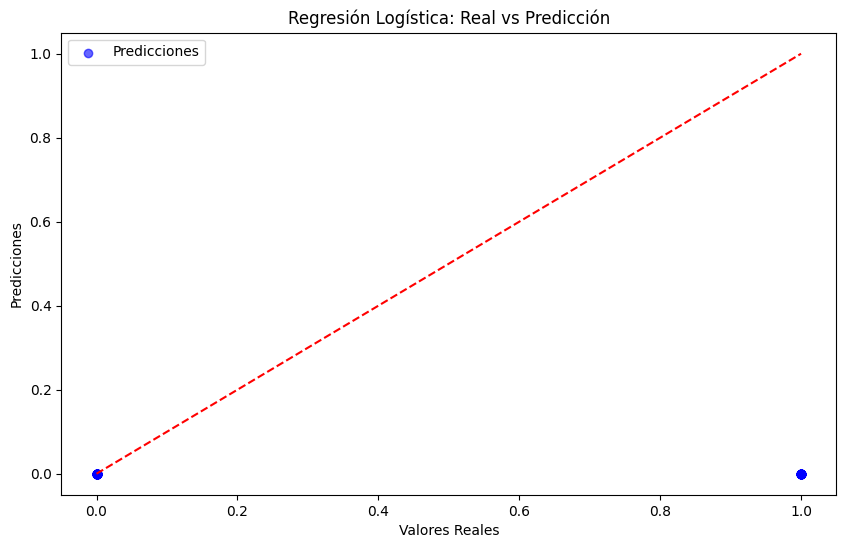

In [101]:
# Regresion logistica
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Crear y entrenar el modelo
model_logistic = LogisticRegression()
model_logistic.fit(X_train, y_train)

# Hacer predicciones
y_pred_logistic = model_logistic.predict(X_test)

# Evaluar el modelo
print("Regresión Logística - Precisión:", accuracy_score(y_test, y_pred_logistic))

# Gráfico de valores reales vs predicciones para la regresión logística
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_logistic, color='blue', label='Predicciones', alpha=0.6)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de 45 grados (ideal)
plt.title('Regresión Logística: Real vs Predicción')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.show()


Árbol de Decisión - Precisión: 0.5952380952380952


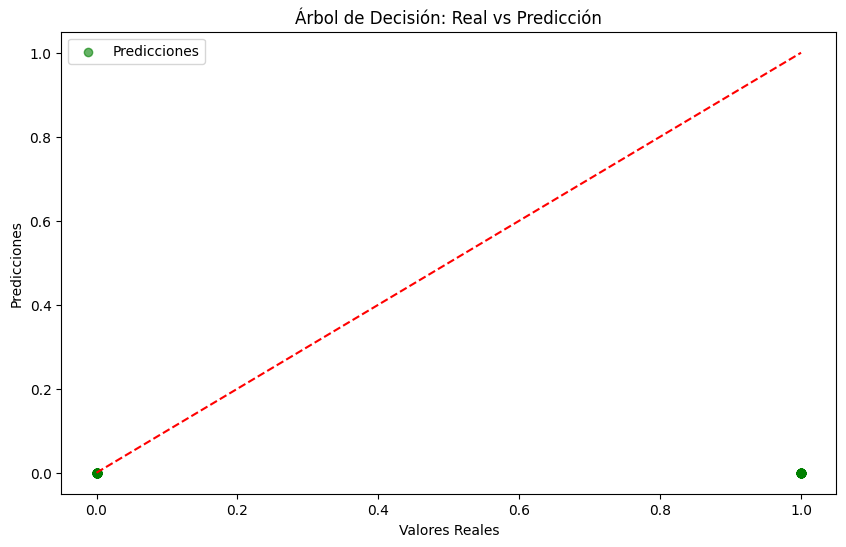

In [102]:
# Arbol de decision
from sklearn.tree import DecisionTreeClassifier

# Crear y entrenar el modelo
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)

# Hacer predicciones
y_pred_tree = model_tree.predict(X_test)

# Evaluar el modelo
print("Árbol de Decisión - Precisión:", accuracy_score(y_test, y_pred_tree))

# Gráfico de valores reales vs predicciones para el árbol de decisión
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_tree, color='green', label='Predicciones', alpha=0.6)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de 45 grados (ideal)
plt.title('Árbol de Decisión: Real vs Predicción')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.show()


SVM - Precisión: 0.5952380952380952


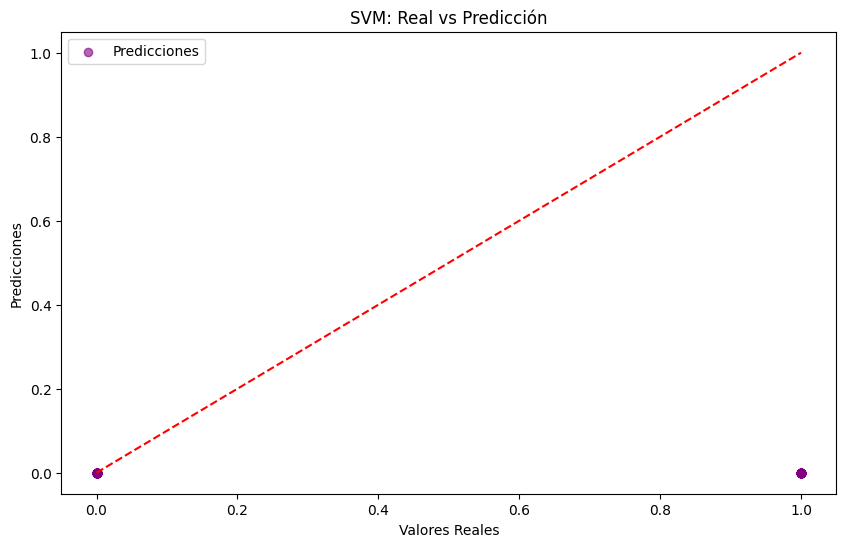

In [103]:
# SVM maquina de soporte vectorial
from sklearn.svm import SVC

# Crear y entrenar el modelo
model_svm = SVC(random_state=42)
model_svm.fit(X_train, y_train)

# Hacer predicciones
y_pred_svm = model_svm.predict(X_test)

# Evaluar el modelo
print("SVM - Precisión:", accuracy_score(y_test, y_pred_svm))

# Gráfico de valores reales vs predicciones para SVM
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_svm, color='purple', label='Predicciones', alpha=0.6)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de 45 grados (ideal)
plt.title('SVM: Real vs Predicción')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.show()



Random Forest - Precisión: 0.5952380952380952


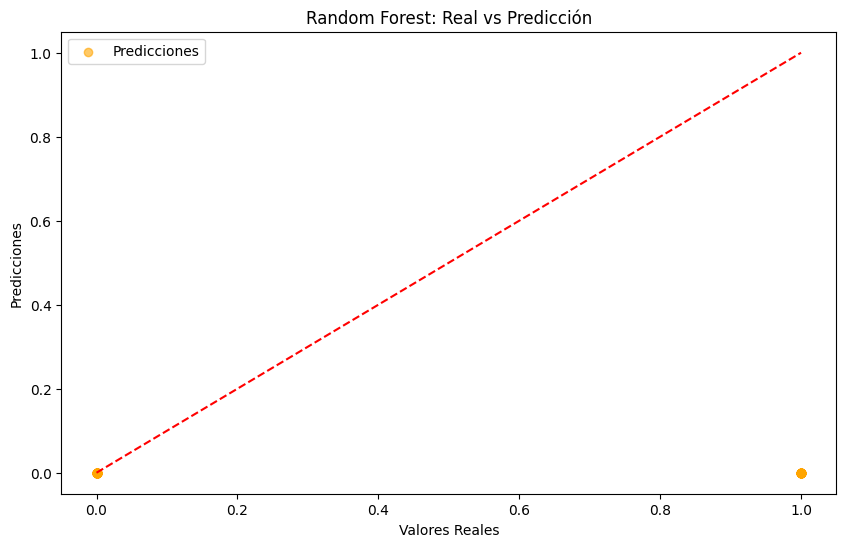

In [104]:
# Random forest
from sklearn.ensemble import RandomForestClassifier

# Crear y entrenar el modelo
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

# Hacer predicciones
y_pred_rf = model_rf.predict(X_test)

# Evaluar el modelo
print("Random Forest - Precisión:", accuracy_score(y_test, y_pred_rf))

# Gráfico de valores reales vs predicciones para Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, color='orange', label='Predicciones', alpha=0.6)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de 45 grados (ideal)
plt.title('Random Forest: Real vs Predicción')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.show()



KNN - Precisión: 0.5952380952380952


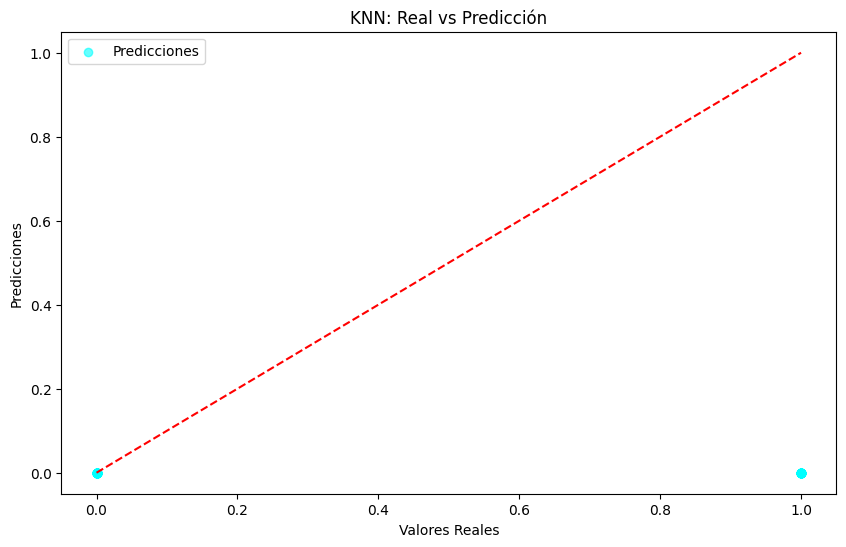

In [105]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

# Crear y entrenar el modelo
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

# Hacer predicciones
y_pred_knn = model_knn.predict(X_test)

# Evaluar el modelo
print("KNN - Precisión:", accuracy_score(y_test, y_pred_knn))

# Gráfico de valores reales vs predicciones para KNN
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_knn, color='cyan', label='Predicciones', alpha=0.6)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea de 45 grados (ideal)
plt.title('KNN: Real vs Predicción')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.show()


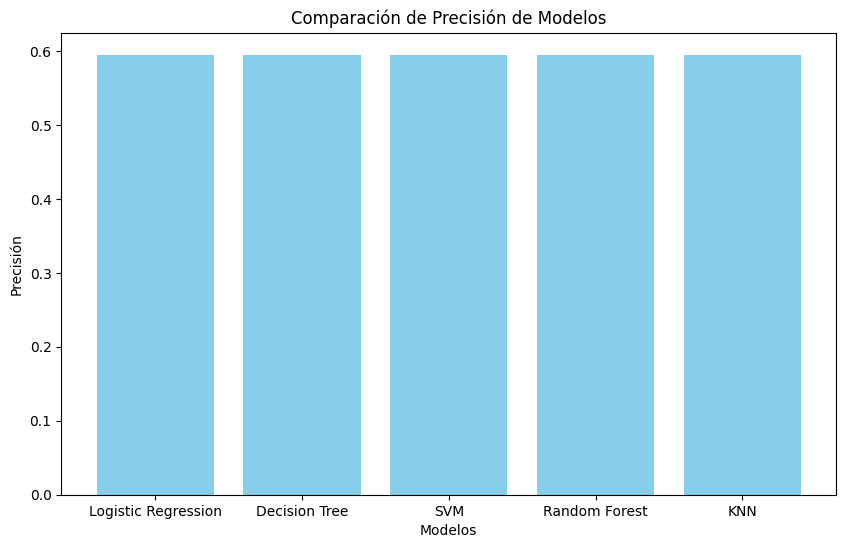

In [100]:
# Visualizacion
import matplotlib.pyplot as plt

# Almacenar las precisiones de los modelos
models = ['Logistic Regression', 'Decision Tree', 'SVM', 'Random Forest', 'KNN']
accuracies = [
    accuracy_score(y_test, y_pred_logistic),
    accuracy_score(y_test, y_pred_tree),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_knn)
]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color='skyblue')

# Títulos y etiquetas
plt.title('Comparación de Precisión de Modelos')
plt.xlabel('Modelos')
plt.ylabel('Precisión')
plt.show()
